---
title: "Modul 8 Sains Data: Pengantar Pytorch"
subtitle: "Pengenalan Deep Learning dengan Pytorch"
image: https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/pytorch.png
description: "Offline di Departemen Matematika"
date: 05/06/2026
page-navigation: true
format: html
---

Kembali ke [Sains Data](./saindat2026genap.qmd)

Ini adalah materi terakhir praktikum Sains Data tahun ini.

Di pertemuan-pertemuan sebelumnya, kita sudah membahas tentang *neural network* dan *deep learning* dengan TensorFlow dan Keras. Dari segi materi mata kuliah Sains Data, sebenarnya kita sudah selesai.

Namun, di awal [Modul 5](./modul5.ipynb), telah disebutkan bahwa ada dua *framework* utama yang umum digunakan untuk *deep learning* di Python, yaitu TensorFlow (dengan Keras) dan PyTorch.

Agar wawasan kita lebih luas dan tidak terbatas satu *framework* saja, tidak ada salahnya kita coba mempelajari PyTorch juga :)

Lagipula, untuk riset/penelitian di dunia *deep learning*, saat ini PyTorch jauh lebih sering digunakan dibandingkan TensorFlow:

![(Gambar tren November 2014 hingga April 2024: dari semua implementasi atau kode yang telah dibuat untuk paper *deep learning*, berapa persen menggunakan *framework* tertentu. Pada April 2024, persentase PyTorch lebih dari 50%, sedangkan persentase TensorFlow kurang dari 10%.)](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/paperswithcode_nov14_apr24.png)

Gambar tren November 2014 hingga April 2024: dari semua implementasi atau kode yang telah dibuat untuk paper *deep learning*, berapa persen menggunakan *framework* tertentu. Pada April 2024, persentase PyTorch lebih dari 50%, sedangkan persentase TensorFlow kurang dari 10%.

Kalian bisa *explore* di *link* berikut: <https://paperswithcode.com/trends>

Apabila sewaktu-waktu kalian ingin menjalani skripsi atau semacamnya di dunia *deep learning*, atau setidaknya ingin membaca riset terbaru, kami harap wawasan tentang PyTorch ini bermanfaat.

::: {.callout-note}
## Tentang urutan materi

Kami sengaja mengajarkan TensorFlow dan Keras terlebih dahulu, baru mengajarkan PyTorch, karena penyusunan model di PyTorch mirip dengan penggunaan *subclassing API* di Keras.

:::

Sebelum kita mulai, instal terlebih dahulu PyTorch, dengan menginstal `torch` dan `torchvision`

In [ ]:
pip install torch torchvision

- `torch` adalah PyTorch.
- `torchvision` menyediakan fitur-fitur yang membantu ketika berurusan dengan gambar, bahkan seperti sudah menjadi bagian yang tidak terpisahkan dari `torch`.
- Sebenarnya ada juga `torchaudio` yang membantu ketika berurusan dengan data suara. Boleh saja kalian instal juga:

    `pip install torch torchvision torchaudio`

Terkait penginstalan PyTorch, kalian bisa membaca lebih lanjut di sini: <https://pytorch.org/get-started/locally/>

Kalau sudah instal, jangan lupa *import*:

In [1]:
import torch, torchvision

Kita bisa lihat versinya (mungkin di kalian akan lebih baru):

In [ ]:
print(torch.__version__)

2.1.0


In [ ]:
print(torchvision.__version__)

0.16.0


Jangan lupa *import* juga *library* yang biasa kita gunakan:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mengenal PyTorch

### CPU, GPU, dan *device-agnostic code*

Tiap komputer bisa memiliki kekuatan yang berbeda, termasuk ada/tiadanya komponen yang bernama GPU.

Tiap komputer pasti punya yang namanya CPU atau *Central Processing Unit*, yang biasanya menjadi pusat segala komputasi di komputer itu, sesuai namanya.

Namun, untuk perhitungan dengan matriks, tensor atau semacamnya, GPU atau *Graphics Processing Unit* lebih cepat. Perhitungan seperti itu biasa dilakukan untuk tampilan atau *graphics* ketika sedang bermain *game*, dan juga biasa dilakukan ketika berurusan dengan *neural network*.

Sehingga, daripada menggunakan CPU, ada baiknya menggunakan GPU, **kalau ada**.

Di Google Colaboratory, di menu `Runtime > Change runtime type`, di bagian *hardware accelerator*, kalian bisa mengubah *setting*, apakah ingin menggunakan CPU atau GPU. (Bahkan, ada juga TPU atau *tensor processing unit* yang sepertinya lebih dikhususkan lagi untuk komputasi dengan tensor.)

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/colabgpu_runtime.png)

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/colabgpu_hardware_accelerator.png)

Apapun yang tersedia, **tiap kali kita ingin menggunakan PyTorch,** sebaiknya kita beritahu, mana yang ingin kita gunakan. Agar tidak berantakan, caranya bisa dengan kode berikut:

In [3]:
# Setup device-agnostic code
if torch.cuda.is_available():
    device = "cuda" # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = "mps" # Apple GPU
else:
    device = "cpu" # Defaults to CPU if NVIDIA GPU/Apple GPU aren't available

print(f"Using device: {device}")

Using device: cuda


Sumber kode: <https://www.learnpytorch.io/pytorch_cheatsheet/#device-agnostic-code-using-pytorch-on-cpu-gpu-or-mps>

*Output* nya akan sesuai dengan pilihan terbaik yang ada, antara CPU atau GPU.

Kode di atas sebenarnya hanya menyimpan pilihan tersebut sebagai *string* ke dalam variabel `device`. Namun, variabel ini nantinya akan digunakan selama berurusan dengan PyTorch.

Sehingga, apabila kita ingin ganti dari CPU ke GPU atau sebaliknya, kita tinggal mengubah isi variabel `device` ini (misalnya menggunakan kode di atas), tidak perlu mengubah kode PyTorch yang sudah kita buat.

Dengan demikian, kode PyTorch yang sudah kita buat menjadi tidak tergantung *device* yang digunakan (apakah CPU atau GPU), atau disebut *device-agnostic*.

## Tensor

Seperti di TensorFlow, di PyTorch juga ada tensor. Cara membuatnya adalah dengan `torch.tensor`

Contohnya, skalar:

In [4]:
tensor0 = torch.tensor(1.5)

In [5]:
print(tensor0)

tensor(1.5000)


In [6]:
print(type(tensor0))

<class 'torch.Tensor'>


Kita bisa melihat dimensinya (rank/dimensi tensor) melalui `.ndim`

In [7]:
print(tensor0.ndim)

0


Tipe datanya berupa `torch.tensor` tapi kita bisa memperoleh nilai skalarnya dengan `.item()`

In [8]:
tensor0.item()

1.5

In [9]:
type(tensor0.item())

float

Contoh lain, array/vektor:

In [10]:
tensor1 = torch.tensor([2.31, 4.567, 8.9])

In [11]:
print(tensor1)

tensor([2.3100, 4.5670, 8.9000])


In [12]:
print(tensor1.ndim)

1


Selain dimensi tensor, ada juga `.shape` yang di sini melambangkan ukuran array/vektor, seperti `.shape` di numpy

In [13]:
print(tensor1.shape)

torch.Size([3])


Nilai suatu elemen di tensor juga bisa diubah:

In [14]:
tensor1[0] = 52.5

In [15]:
print(tensor1)

tensor([52.5000,  4.5670,  8.9000])


Ada juga tipe data:

In [16]:
print(tensor1.dtype)

torch.float32


Seperti tensor di TensorFlow, tensor di PyTorch juga biasanya menggunakan bilangan *float* yang 32-bit daripada 64-bit.

Contoh lagi, matriks:

In [17]:
mat1 = torch.tensor([
    [1, 2.718, 3.14],
    [4, 5, 6.28]
])

In [18]:
print(mat1)

tensor([[1.0000, 2.7180, 3.1400],
        [4.0000, 5.0000, 6.2800]])


In [19]:
print(mat1.ndim)

2


In [20]:
print(mat1.shape)

torch.Size([2, 3])


Kita bisa buat matriks kedua, lalu mengalikannya dengan perkalian matriks menggunakan `torch.matmul`

In [21]:
mat2 = torch.tensor([
    [9, 8],
    [7, 6],
    [5, 4.3]
])

In [22]:
print(mat2.ndim)
print(mat2.shape)
print(mat2.dtype)

2
torch.Size([3, 2])
torch.float32


In [23]:
mat3 = torch.matmul(mat1, mat2)

In [24]:
print(mat3)

tensor([[ 43.7260,  37.8100],
        [102.4000,  89.0040]])


Matriks juga bisa ditranspos dengan `.T`

In [25]:
mat4 = mat3.T
print(mat4)

tensor([[ 43.7260, 102.4000],
        [ 37.8100,  89.0040]])


## Konversi dari/ke numpy

Kita bisa mengonversi tensor PyTorch menjadi array numpy dan sebaliknya:

- `.numpy()` untuk mengubah suatu tensor PyTorch menjadi array numpy

- `torch.from_numpy(...)` untuk mengubah suatu array numpy menjadi tensor PyTorch

In [26]:
arr5 = mat4.numpy()
print(arr5)
print(type(arr5))
print(arr5.dtype)

[[ 43.725998 102.4     ]
 [ 37.81      89.004005]]
<class 'numpy.ndarray'>
float32


In [27]:
mat6 = torch.from_numpy(arr5)
print(mat6)
print(type(mat6))
print(mat6.dtype)

tensor([[ 43.7260, 102.4000],
        [ 37.8100,  89.0040]])
<class 'torch.Tensor'>
torch.float32


## ones, zeros, rand, randn

Kita bisa membuat tensor berisi satu semua, atau nol semua, atau nilai random, dengan ukuran `size` yang bisa kita tentukan

In [28]:
x = torch.ones(size = (3,4))
print(x)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [29]:
x = torch.zeros(size = (3,4))
print(x)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [30]:
x = torch.rand(size = (3,4))
print(x)

tensor([[0.4802, 0.5363, 0.7343, 0.2530],
        [0.3819, 0.5722, 0.6758, 0.9304],
        [0.4217, 0.7339, 0.4435, 0.4918]])


`torch.rand` memilih nilai secara random dari distribusi uniform pada interval $[0,1)$

Untuk memilih nilai secara random dari distribusi normal (dengan $\mu = 0$ dan $\sigma = 1$), gunakan `torch.randn`

In [31]:
x = torch.randn(size = (3,4))
print(x)

tensor([[ 0.2670, -0.7715,  0.8723,  0.8650],
        [-0.4971,  0.3538, -0.6294, -2.4212],
        [ 0.1309, -0.2430,  1.1328, -0.2099]])


## Operasi tensor seperti numpy

Secara umum, operasi tensor di PyTorch memang mirip dengan array di numpy, sebagaimana operasi tensor di TensorFlow juga mirip dengan array di numpy.

In [32]:
a = 4 * torch.ones((2, 2))
print(a)

tensor([[4., 4.],
        [4., 4.]])


In [33]:
b = torch.square(a)
print(b)

tensor([[16., 16.],
        [16., 16.]])


In [34]:
c = torch.sqrt(a)
print(c)

tensor([[2., 2.],
        [2., 2.]])


In [35]:
d = b + c
print(d)

tensor([[18., 18.],
        [18., 18.]])


In [36]:
# perkalian matriks
e = torch.matmul(a, c)
print(e)

tensor([[16., 16.],
        [16., 16.]])


In [37]:
# perkalian per elemen
e *= d
print(e)

tensor([[288., 288.],
        [288., 288.]])


In [38]:
# penjumlahan per elemen
f = e + 2
print(f)

tensor([[290., 290.],
        [290., 290.]])


## *Autograd* dengan `.backward()`

Sebagaimana ada *automatic differentiation* atau *autodiff* di TensorFlow, ada juga autograd di PyTorch. Namun, *syntax* nya cukup berbeda.

Caranya, inputnya kita jadikan tensor dengan parameter `requires_grad=True`, lalu kita operasikan (misal dengan fungsi f) dan menghasilkan tensor baru, lalu di tensor baru ini kita panggil `.backward()` agar turunan f dihitung dan disimpan di variabel input `.grad`

Contohnya, turunan $x^3$ terhadap $x$ di $x=4$ adalah $3(4)^2 = 48$.

In [39]:
# siapkan input, dengan requires_grad=True
x = torch.tensor(4.0, requires_grad=True)

# hitung fungsi F
F = x**3

# jalankan perhitungan turunan F (terhadap input)
F.backward()

# tampilkan turunan yang tersimpan di input .grad
print(x.grad)

tensor(48.)


Nama *method* nya adalah `.backward()` dan memang digunakan di *backward pass* (akan kita lihat nanti).

Contoh lain, turunan $3x^3 - y^2$ terhadap $x$ dengan $x=2$ adalah $9(2)^2 = 36$, dan turunannya terhadap $y$ dengan $y=6$ adalah $-2(6) = -12$

In [40]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(6.0, requires_grad=True)

F = 3 * x**3 - y**2

F.backward()

print(x.grad)
print(y.grad)

tensor(36.)
tensor(-12.)


# Klasifikasi biner dengan *perceptron*

## Persiapan data, `TensorData`, `DataLoader`

Untuk model pertama kita, mari kita coba buat kembali model *perceptron* untuk klasifikasi biner yang pernah kita buat di [Modul 5](./modul5.ipynb), dengan dataset `titik_negatif_positif.csv` yang sama, bisa kalian *download* dari GitHub Pages ini: [titik_negatif_positif.csv](./modul5/titik_negatif_positif.csv)

Kita buka datasetnya, jangan lupa dengan `dtype="float32"` karena itulah tipe data yang biasa digunakan oleh PyTorch, seperti TensorFlow:

In [41]:
titik_df = pd.read_csv("./titik_negatif_positif.csv", dtype="float32")

In [42]:
titik_df

,x,y,kelas
0,-0.221076,2.588921,0.0
1,-1.033520,2.082779,0.0
2,0.592823,2.813897,0.0
3,-0.600524,2.456575,0.0
4,0.408931,2.819284,0.0
...,...,...,...
1995,2.464286,-2.095284,1.0
1996,2.289086,-0.187182,1.0
1997,2.195790,-1.183157,1.0
1998,2.774544,-0.433664,1.0


Memisahkan antara inputs (prediktor) dan targets (variabel target):

In [43]:
titik_inputs_df = titik_df.drop(columns=["kelas"])
titik_targets_df = titik_df[["kelas"]]

In [44]:
titik_inputs_df

,x,y
0,-0.221076,2.588921
1,-1.033520,2.082779
2,0.592823,2.813897
3,-0.600524,2.456575
4,0.408931,2.819284
...,...,...
1995,2.464286,-2.095284
1996,2.289086,-0.187182
1997,2.195790,-1.183157
1998,2.774544,-0.433664


In [45]:
titik_targets_df

,kelas
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
1995,1.0
1996,1.0
1997,1.0
1998,1.0


Mengubahnya menjadi *array* numpy:

In [46]:
titik_inputs_arr = titik_inputs_df.to_numpy()
titik_targets_arr = titik_targets_df.to_numpy()

Kemudian mengubahnya menjadi tensor PyTorch:

In [47]:
titik_inputs_tensor = torch.from_numpy(titik_inputs_arr)
titik_targets_tensor = torch.from_numpy(titik_targets_arr)

Tujuan mengubah dari DataFrame menjadi tensor, tentunya supaya bisa diproses dengan PyTorch.

Kita bisa periksa, bentuknya sesuai:

In [48]:
print(titik_inputs_tensor)

tensor([[-0.2211,  2.5889],
        [-1.0335,  2.0828],
        [ 0.5928,  2.8139],
        ...,
        [ 2.1958, -1.1832],
        [ 2.7745, -0.4337],
        [ 3.9170,  0.9042]])


In [49]:
print(titik_targets_tensor)

tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]])


Kemudian, kita bisa melakukan *train-validation-test split*, misalnya dengan rasio 80:10:10

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
# data utuh menjadi data train 80% dan data "test" 20%
titik_X_train, titik_X_test, titik_y_train, titik_y_test = train_test_split(
    titik_inputs_tensor, titik_targets_tensor, test_size=0.2, random_state=42
)

# data "test" dibagi dua, menjadi data validation dan data test sesungguhnya
titik_X_val, titik_X_test, titik_y_val, titik_y_test = train_test_split(
    titik_X_test, titik_y_test, test_size=0.5, random_state=42
)

Kita bisa periksa ukurannya, rasionya sudah sesuai yang kita tetapkan:

In [52]:
print(titik_X_train.shape)
print(titik_X_val.shape)
print(titik_X_test.shape)

torch.Size([1600, 2])
torch.Size([200, 2])
torch.Size([200, 2])


Sebelum dataset kita benar-benar siap untuk diproses dengan PyTorch, ada dua hal yang perlu kita lakukan:

1. mengubahnya menjadi objek `Dataset` dengan `TensorDataset`

    `Dataset` di sini adalah format dataset umum yang dikenal oleh PyTorch.

2. mengubah objek `Dataset` menjadi objek `DataLoader`

    `DataLoader` membuat objek `Dataset` menjadi *"iterable"* yaitu bisa diiterasikan dengan *for loop*, agar bisa digunakan dalam proses *training* maupun *testing*.

Baik `TensorDataset` maupun `DataLoader` bisa kita import dari `torch.utils.data`

In [53]:
from torch.utils.data import TensorDataset, DataLoader

Masing-masing dari data train, data validation, dan data test bisa kita ubah menjadi objek `Dataset` dengan menentukan mana prediktor dan mana target:

In [54]:
titik_train_dataset = TensorDataset(titik_X_train, titik_y_train)
titik_val_dataset = TensorDataset(titik_X_val, titik_y_val)
titik_test_dataset = TensorDataset(titik_X_test, titik_y_test)

Kemudian, masing-masing bisa kita ubah menjadi `DataLoader`, sekasligus menentukan *batch size*, dan juga menentukan apakah perlu ada *shuffling* di tiap epoch (biasanya dilakukan di data *train* untuk mengurangi *overfitting*):

In [55]:
titik_train_dataloader = DataLoader(titik_train_dataset, batch_size=32, shuffle=True)
titik_val_dataloader = DataLoader(titik_val_dataset, batch_size=32, shuffle=False)
titik_test_dataloader = DataLoader(titik_test_dataset, batch_size=32, shuffle=False)

## Menyusun model

Ingat bahwa *perceptron* yang ingin kita susun hanya terdiri dari

- *input layer* dengan dua *neuron*,

- tidak ada *hidden layer*,

- *output layer* dengan satu *neuron* dan fungsi aktivasi sigmoid

Sehingga matriks bobot yang sesuai berukuran $2 \times 1$, dan vektor bias yang sesuai berukuran $1 \times 1$.

Di PyTorch, tiap model berupa *class* dengan ketentuan:

- meng-*inherit* dari `torch.nn.Module` (yaitu *base class* untuk semua model PyTorch)

- baris pertama di *constructor* `__init__` adalah

    `super().__init__()`

- harus mendefinisikan `forward()` untuk *forward pass*

- komponen/variabel/atribut/parameter yang diperlukan biasanya didefinisikan di *constructor*

    Catatan: parameter biasa didefinisikan dengan `torch.nn.Parameter` daripada `torch.tensor`

Ini cukup mirip dengan *subclassing API* di Keras, yang meng-*inherit* dari `keras.Model` dan harus mendefinisikan `call()` untuk *forward pass*.

Mari kita susun *perceptron* kita, yang memiliki matriks bobot, vektor bias, dan fungsi aktivasi sigmoid:

In [56]:
class MyPerceptron(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(
            torch.randn(size = (2, 1), dtype = torch.float32),
            requires_grad=True # agar autgrad aktif
        )

        self.bias = torch.nn.Parameter(
            torch.randn(size = (1,), dtype = torch.float32),
            requires_grad=True
        )

    def forward(self, x):
        return torch.sigmoid(
            torch.matmul(x, self.weights) + self.bias
        )

Kita bisa buat suatu *instance* atau objek dari *class* di atas:

In [57]:
pisah_titik = MyPerceptron()

Ini adalah model yang siap di-*train*. Sebelum *training*, kita bisa memeriksa parameter model (saat ini masih random sesuai `torch.randn`):

In [58]:
list(pisah_titik.parameters())

[Parameter containing:
 tensor([[-0.0342],
         [-0.5450]], requires_grad=True),
 Parameter containing:
 tensor([-0.4606], requires_grad=True)]

Mirip, ada juga yang namanya `.state_dict()`

In [59]:
pisah_titik.state_dict()

OrderedDict([('weights',
              tensor([[-0.0342],
                      [-0.5450]])),
             ('bias', tensor([-0.4606]))])

## Menyiapkan *hyperparameter*

Untuk klasifikasi, *loss function* yang biasa digunakan adalah *crossentropy loss*, atau mungkin lebih spesifiknya *binary crossentropy loss*, yang disebut `torch.nn.BCELoss` di PyTorch. Kita bisa menyiapkannya sebagai objek.

In [60]:
titik_loss_fn = torch.nn.BCELoss()

Serupa, *optimizer* juga disiapkan sebagai objek, misalnya `torch.optim.SGD` untuk SGD *(stochastic gradient descent)*:

In [61]:
titik_opt = torch.optim.SGD(params=pisah_titik.parameters(), # merujuk ke parameter model
                            lr=0.01) # learning rate

## *Training loop*

Mungkin agak mengejutkan: di PyTorch, kita dibebaskan untuk membuat *training loop* sendiri. Artinya, tidak ada fungsi `.fit()` yang tinggal kita panggil; kita perlu menyusun *for loop* sendiri, seperti di [Modul 6](./modul6.ipynb) :)

Ingat kembali, tiap iterasi (yaitu per *batch*) di proses *training* melibatkan:

1. *Forward pass*: menghitung nilai *output* (hasil prediksi) dari *input* (*batch*).

2. Menghitung *loss* antara hasil prediksi dan nilai sebenarnya

3. *Backpropagation*: menghitung gradien dari *loss* terhadap tiap parameter

4. *Update optimizer*: memperbarui nilai parameter berdasarkan gradien dari *loss*, menggunakan rumus atau *optimizer* yang dipilih

Ingat juga, selain *training*, ada juga yang namanya *validation* (atau terkadang disebut *testing* di beberapa sumber). Tahap *validation* ini menguji model di akhir tiap *epoch*, setelah semua *batch* melalui proses *training*. Langkahnya terdiri dari:

1. *Forward pass*

2. Menghitung *loss* dan/atau *accuracy* antara hasil prediksi dan nilai sebenarnya

Perhatikan bahwa *validation* juga bisa dilakukan per *batch*, sehingga kedua langkah di atas dilakukan per *batch*. Kalau begitu, nilai akhir untuk *loss* dan/atau *accuracy* menjadi rata-rata dari nilainya di tiap *batch*.

Penjelasan di atas menjadi kode PyTorch sebagai berikut:

In [62]:
epochs = 10

train_loss_list = []
val_loss_list = []

# untuk tiap epoch,
for epoch in range(epochs):
    # siapkan model untuk tahap training
    pisah_titik.to(device)
    pisah_titik.train()
    sum_train_loss = 0

    # untuk tiap batch,
    for X, y in titik_train_dataloader:
        X = X.to(device)
        y = y.to(device)

        # Forward pass
        y_pred = pisah_titik(X)

        # Hitung loss
        loss = titik_loss_fn(y_pred, y)
        sum_train_loss += loss

        # "Optimizer zero grad": nolkan dulu hasil hitung gradien
        titik_opt.zero_grad()

        # Backpropagation
        loss.backward()

        # Update optimizer, juga disebut "optimizer step"
        titik_opt.step()

    # hitung rata-rata train loss berdasarkan banyaknya batch
    avg_train_loss = sum_train_loss / len(titik_train_dataloader)

    # simpan train loss
    train_loss_list.append(avg_train_loss)

    # siapkan model untuk tahap validaion
    pisah_titik.to(device)
    pisah_titik.eval()
    sum_val_loss = 0

    # selalu digunakan ketika hendak testing
    with torch.inference_mode():
        # untuk tiap batch,
        for X, y in titik_val_dataloader:
            X = X.to(device)
            y = y.to(device)

            # Forward pass
            y_pred = pisah_titik(X)

            # Hitung loss
            sum_val_loss += titik_loss_fn(y_pred, y)

        # hitung rata-rata val loss berdasarkan banyaknya batch
        avg_val_loss = sum_val_loss / len(titik_val_dataloader)

        # simpan val loss
        val_loss_list.append(avg_val_loss)

    # tampilkan train loss dan val loss untuk epoch ini
    print(f"Epoch: {epoch} | avg train loss: {avg_train_loss} | avg val loss: {avg_val_loss}")

Epoch: 0 | avg train loss: 0.41030749678611755 | avg val loss: 0.26513242721557617
Epoch: 1 | avg train loss: 0.230312779545784 | avg val loss: 0.17859508097171783
Epoch: 2 | avg train loss: 0.16645433008670807 | avg val loss: 0.139607772231102
Epoch: 3 | avg train loss: 0.1341838389635086 | avg val loss: 0.11674195528030396
Epoch: 4 | avg train loss: 0.11412017792463303 | avg val loss: 0.10137594491243362
Epoch: 5 | avg train loss: 0.10017082840204239 | avg val loss: 0.09015743434429169
Epoch: 6 | avg train loss: 0.08978377282619476 | avg val loss: 0.08153384923934937
Epoch: 7 | avg train loss: 0.08168092370033264 | avg val loss: 0.07465149462223053
Epoch: 8 | avg train loss: 0.07515193521976471 | avg val loss: 0.06900966167449951
Epoch: 9 | avg train loss: 0.06974836438894272 | avg val loss: 0.06428851187229156


Perhatikan bahwa hasil *loss* di tiap *epoch* sudah kita simpan ke dalam list.

In [63]:
print(train_loss_list)
print(val_loss_list)

[tensor(0.4103, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.2303, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.1665, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.1342, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.1141, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.1002, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.0898, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.0817, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.0752, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.0697, device='cuda:0', grad_fn=<DivBackward0>)]
[tensor(0.2651, device='cuda:0'), tensor(0.1786, device='cuda:0'), tensor(0.1396, device='cuda:0'), tensor(0.1167, device='cuda:0'), tensor(0.1014, device='cuda:0'), tensor(0.0902, device='cuda:0'), tensor(0.0815, device='cuda:0'), tensor(0.0747, device='cuda:0'), tensor(0.0690, device='cuda:0'), tensor(0.0643, device='cuda:0')]


Maka, kita bisa ubah jadi DataFrame lalu menyimpannya sebagai CSV:

In [64]:
titik_loss_df = pd.DataFrame(
    [
        [loss.item() for loss in train_loss_list],
        [loss.item() for loss in val_loss_list]
    ],
).transpose().rename(columns={0: "train_loss", 1: "val_loss"})

In [65]:
titik_loss_df

,train_loss,val_loss
0,0.410307,0.265132
1,0.230313,0.178595
2,0.166454,0.139608
3,0.134184,0.116742
4,0.114120,0.101376
5,0.100171,0.090157
6,0.089784,0.081534
7,0.081681,0.074651
8,0.075152,0.069010
9,0.069748,0.064289


In [66]:
titik_loss_df.to_csv("./pytorch_titik_loss_df.csv", index=False)

Kalau mau menyamakan dengan modul, kalian bisa *download* melalui GitHub Pages ini: [pytorch_titik_loss_df.csv](./modul8/pytorch_titik_loss_df.csv)

Kita bisa import kembali:

In [67]:
pytorch_titik_loss_df = pd.read_csv("./pytorch_titik_loss_df.csv")

Lalu kita bisa plot:

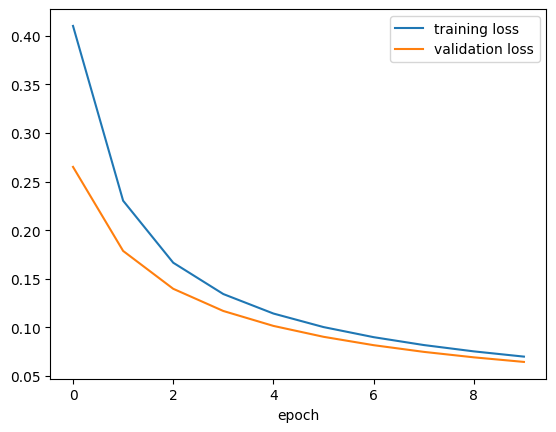

In [68]:
plt.plot(pytorch_titik_loss_df["train_loss"], label = "training loss")
plt.plot(pytorch_titik_loss_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

## Prediksi

## Menyimpan parameter model (saja)

Ingat kembali, kita bisa melihat parameter model dengan `.state_dict()`

In [69]:
pisah_titik.state_dict()

OrderedDict([('weights',
              tensor([[ 1.0982],
                      [-0.9789]], device='cuda:0')),
             ('bias', tensor([-0.2610], device='cuda:0'))])

Kita bisa menyimpan parameter model ke dalam *file* berakhiran `.pth` menggunakan `torch.save`

In [70]:
torch.save(pisah_titik.state_dict(), "./pisah_titik_state.pth")

Apabila ingin *load* kembali, kita perlu membuat *instance* terlebih dahulu...

In [71]:
pisah_titik2 = MyPerceptron()

Barulah kita panggil `.load_state_dict(torch.load(PATH))` seperti berikut:

In [72]:
pisah_titik2.load_state_dict(torch.load("./pisah_titik_state.pth"))

<All keys matched successfully>

Parameternya akan sama:

In [73]:
pisah_titik2.state_dict()

OrderedDict([('weights',
              tensor([[ 1.0982],
                      [-0.9789]])),
             ('bias', tensor([-0.2610]))])

## `torch.nn.Linear` dan `torch.nn.Sequential`

In [74]:
class MyPerceptron_v2(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # satu dense layer dengan fungsi aktivasi linier
        self.linear_layer = torch.nn.Linear(in_features=2, out_features=1)

        # fungsi aktivasi sigmoid
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.linear_layer(x)
        x = self.sigmoid(x)
        return x

In [75]:
class MyPerceptron_v3(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # perhatikan: inputnya bukan berupa list, langsung saja tiap layer
        self.layer = torch.nn.Sequential(
            torch.nn.Linear(in_features=2, out_features=1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.layer(x)
        return x

# Fungsi *train step* dan *val step*

*Training loop* kita terdiri dari dua bagian utama, yaitu tahap *training* dan tahap *validation*. Kita bisa menyusun *training loop* yang telah kita buat dengan lebih rapi, dengan memasukkan tiap tahap ke dalam fungsi yang nantinya tinggal dipanggil. Modifikasi yang dilakukan:

- `pisah_titik` menjadi `model`

- `titik_train_dataloader` menjadi `train_dataloader`

- `titik_val_dataloader` menjadi `val_dataloader`

- `titik_loss_fn` menjadi `loss_fn`

- `titik_opt` menjadi `optimizer`

In [76]:
def train_step(model, train_dataloader, loss_fn, optimizer, device=device):
    # siapkan model untuk tahap training
    model.to(device)
    model.train()
    sum_train_loss = 0

    # untuk tiap batch,
    for X, y in train_dataloader:
        X = X.to(device)
        y = y.to(device)

        # Forward pass
        y_pred = model(X)

        # Hitung loss
        loss = loss_fn(y_pred, y)
        sum_train_loss += loss

        # "Optimizer zero grad": nolkan dulu hasil hitung gradien
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update optimizer, juga disebut "optimizer step"
        optimizer.step()

    # hitung rata-rata train loss berdasarkan banyaknya batch
    avg_train_loss = sum_train_loss / len(train_dataloader)

    # sedikit modifikasi: return train loss
    return avg_train_loss

In [77]:
def val_step(model, val_dataloader, loss_fn, device=device):
    # siapkan model untuk tahap validaion
    model.to(device)
    model.eval()
    sum_val_loss = 0

    # selalu digunakan ketika hendak testing
    with torch.inference_mode():
        # untuk tiap batch,
        for X, y in val_dataloader:
            X = X.to(device)
            y = y.to(device)

            # Forward pass
            y_pred = model(X)

            # Hitung loss
            sum_val_loss += loss_fn(y_pred, y)

        # hitung rata-rata val loss berdasarkan banyaknya batch
        avg_val_loss = sum_val_loss / len(val_dataloader)

        # sedikit modifikasi: return val loss
        return avg_val_loss

Setelah mendefinisikan kedua fungsi di atas, *training loop* menjadi lebih sederhana:

In [78]:
epochs = 10

train_loss_list = []
val_loss_list = []

# untuk tiap epoch,
for epoch in range(epochs):
    # training step
    avg_train_loss = train_step(
        model = pisah_titik,
        train_dataloader = titik_train_dataloader,
        loss_fn = titik_loss_fn,
        optimizer = titik_opt,
        device = device
    )
    train_loss_list.append(avg_train_loss)

    # validation step
    avg_val_loss = val_step(
        model = pisah_titik,
        val_dataloader = titik_val_dataloader,
        loss_fn = titik_loss_fn,
        device = device
    )
    val_loss_list.append(avg_val_loss)

    # tampilkan train loss dan val loss untuk epoch ini
    print(f"Epoch: {epoch} | avg train loss: {avg_train_loss} | avg val loss: {avg_val_loss}")

Epoch: 0 | avg train loss: 0.06520413607358932 | avg val loss: 0.060273587703704834
Epoch: 1 | avg train loss: 0.061319682747125626 | avg val loss: 0.05681086704134941
Epoch: 2 | avg train loss: 0.05795380845665932 | avg val loss: 0.05379094183444977
Epoch: 3 | avg train loss: 0.05500468239188194 | avg val loss: 0.05113024637103081
Epoch: 4 | avg train loss: 0.052401311695575714 | avg val loss: 0.048765674233436584
Epoch: 5 | avg train loss: 0.050082553178071976 | avg val loss: 0.04664979130029678
Epoch: 6 | avg train loss: 0.04799758270382881 | avg val loss: 0.04474356397986412
Epoch: 7 | avg train loss: 0.04611767828464508 | avg val loss: 0.04301655665040016
Epoch: 8 | avg train loss: 0.04441233351826668 | avg val loss: 0.04144366458058357
Epoch: 9 | avg train loss: 0.04285372048616409 | avg val loss: 0.040003351867198944


Bahkan, *training loop* secara keseluruhan bisa kita jadikan fungsi juga.

In [79]:
def training_loop(
        model, train_dataloader, val_dataloader,
        loss_fn, optimizer, epochs, device = device
    ):

    train_loss_list = []
    val_loss_list = []

    # untuk tiap epoch,
    for epoch in range(epochs):
        # training step
        avg_train_loss = train_step(
            model, train_dataloader,
            loss_fn, optimizer, device=device
        )
        train_loss_list.append(avg_train_loss)

        # validation step
        avg_val_loss = val_step(
            model, val_dataloader,
            loss_fn, device=device
        )
        val_loss_list.append(avg_val_loss)

        # tampilkan train loss dan val loss untuk epoch ini
        print(f"Epoch: {epoch} | avg train loss: {avg_train_loss} | avg val loss: {avg_val_loss}")

    # menyimpan kedua list ke dalam dictionary yang kemudian di-return
    results_dict = {
        "train_loss": [loss.item() for loss in train_loss_list],
        "val_loss": [loss.item() for loss in val_loss_list]
    }
    return results_dict

# Klasifikasi Gambar

Sekarang kita akan mencoba melakukan klasifikasi gambar dengan dataset Fashion MNIST seperti di pertemuan sebelumnya.

## Persiapan data

Langkah pertama adalah menyiapkan data, yaitu menyiapkan objek `Dataset`, yang kemudian diubah menjadi `DataLoader`. Untungnya, objek `Dataset` untuk Fashion MNIST sudah tersedia di `torchvision.datasets.FashionMNIST` sehingga tinggal kita *download* seperti berikut.

Perkiraan *storage* yang dibutuhkan: 90 MB

Apabila *download* di laptop kalian terlalu pelan, silakan gunakan Google Colaboratory saja, selesai kurang dari 30 detik

In [80]:
fashion_train = torchvision.datasets.FashionMNIST(
    root = "./fashion_data", # folder tempat download
    train = True, # data training
    download = True, # karena belum ada
    # agar file gambar otomatis diubah menjadi tensor
    transform = torchvision.transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.27MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.3MB/s]


In [81]:
fashion_val = torchvision.datasets.FashionMNIST(
    root = "./fashion_data", # folder yang sama untuk tempat download
    train = False, # bukan data training
    download = True,
    transform = torchvision.transforms.ToTensor()
)

Banyaknya baris di data *training* dan data *validation*

In [82]:
print(len(fashion_train.data), len(fashion_train.targets))

60000 60000


In [83]:
print(len(fashion_val.data), len(fashion_val.targets))

10000 10000


Kelas-kelas:

In [84]:
nama_kelas = fashion_train.classes
print(nama_kelas)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Kita bisa lihat salah satu gambarnya:

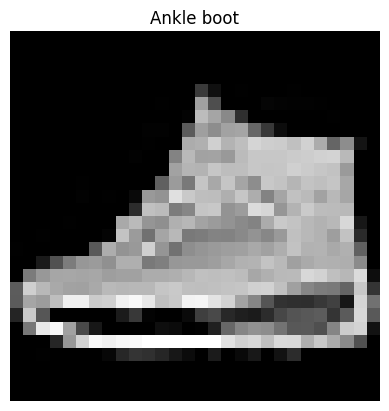

In [85]:
#@title Slider to look for some image examples {run: "auto"}
idx = 21402 #@param {type:"slider", min:0, max:49999, step:1}

image, label = fashion_train[idx]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(nama_kelas[label])
plt.axis('OFF')
plt.show()

Sedikit berbeda dengan pertemuan sebelumnya, kali ini kita gunakan `.squeeze()` karena gambar yang diberikan berukuran 1 x 28 x 28 (yaitu dengan satu *color channel:* hitam-putih) daripada 28 x 28, sehingga perlu diubah menjadi 28 x 28.

Jangan lupa menyiapkan `DataLoader`

In [86]:
BATCH_SIZE = 32

fashion_train_dataloader = DataLoader(
    fashion_train,
    batch_size = BATCH_SIZE,
    shuffle = True
)

fashion_val_dataloader = DataLoader(
    fashion_val,
    batch_size = BATCH_SIZE,
    shuffle = False
)

## Menyusun model

In [87]:
class ModelFashionMNIST(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_stack = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=784, out_features=15),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=15, out_features=10),
            torch.nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.layer_stack(x)
        return x

In [88]:
fashion_model = ModelFashionMNIST()

## Menyiapkan *hyperparameter*

In [89]:
fashion_loss_fn = torch.nn.CrossEntropyLoss()
fashion_opt = torch.optim.Adam(params=fashion_model.parameters(),
                               lr=0.01)

## *Training*

In [90]:
fashion_results = training_loop(
    fashion_model, fashion_train_dataloader, fashion_val_dataloader,
    fashion_loss_fn, fashion_opt,
    epochs = 10,
    device = device
)

Epoch: 0 | avg train loss: 1.8058053255081177 | avg val loss: 1.7479619979858398
Epoch: 1 | avg train loss: 1.7447865009307861 | avg val loss: 1.7382720708847046
Epoch: 2 | avg train loss: 1.743544578552246 | avg val loss: 1.7476904392242432
Epoch: 3 | avg train loss: 1.7371808290481567 | avg val loss: 1.7296620607376099
Epoch: 4 | avg train loss: 1.7381163835525513 | avg val loss: 1.7587523460388184
Epoch: 5 | avg train loss: 1.7400611639022827 | avg val loss: 1.7578251361846924
Epoch: 6 | avg train loss: 1.7344101667404175 | avg val loss: 1.7394795417785645
Epoch: 7 | avg train loss: 1.7391715049743652 | avg val loss: 1.7541440725326538
Epoch: 8 | avg train loss: 1.7360997200012207 | avg val loss: 1.7269995212554932
Epoch: 9 | avg train loss: 1.7359243631362915 | avg val loss: 1.7364836931228638


In [97]:
fashion_loss_df = pd.DataFrame(
    [
        [loss for loss in fashion_results["train_loss"]],
        [loss for loss in fashion_results["val_loss"]]
    ],
).transpose().rename(columns={0: "train_loss", 1: "val_loss"})

In [98]:
fashion_loss_df

,train_loss,val_loss
0,1.805805,1.747962
1,1.744787,1.738272
2,1.743545,1.747690
3,1.737181,1.729662
4,1.738116,1.758752
5,1.740061,1.757825
6,1.734410,1.739480
7,1.739172,1.754144
8,1.736100,1.727000
9,1.735924,1.736484


In [99]:
fashion_loss_df.to_csv("./pytorch_fashion_loss_df.csv", index=False)

Kalau mau menyamakan dengan modul, bisa *download* dari GitHub Pages ini: [pytorch_fashion_loss_df.csv](./modul8/pytorch_fashion_loss_df.csv)

In [100]:
pytorch_fashion_loss_df = pd.read_csv("./pytorch_fashion_loss_df.csv")

In [101]:
pytorch_fashion_loss_df

,train_loss,val_loss
0,1.805805,1.747962
1,1.744787,1.738272
2,1.743545,1.747690
3,1.737181,1.729662
4,1.738116,1.758752
5,1.740061,1.757825
6,1.734410,1.739480
7,1.739172,1.754144
8,1.736100,1.727000
9,1.735924,1.736484


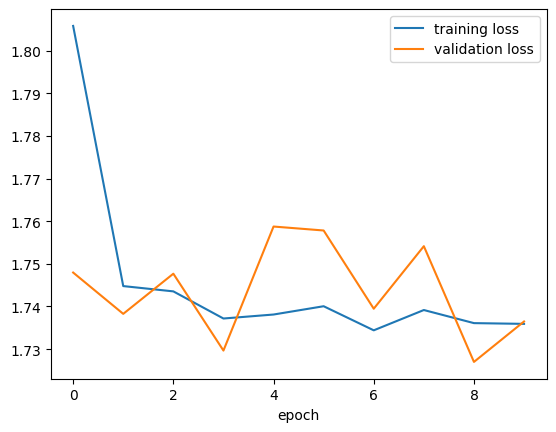

In [102]:
plt.plot(pytorch_fashion_loss_df["train_loss"], label = "training loss")
plt.plot(pytorch_fashion_loss_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

## Prediksi

In [103]:
fashion_val_list = list(fashion_val_dataloader)

In [104]:
tes_batch_gambar, tes_batch_label = fashion_val_list[123]

In [105]:
print(tes_batch_gambar.shape)

torch.Size([32, 1, 28, 28])


In [106]:
print(tes_batch_label.shape)

torch.Size([32])


In [107]:
tes_gambar = tes_batch_gambar[0, :, :, :].to(device)

In [108]:
print(tes_gambar.shape)

torch.Size([1, 28, 28])


In [109]:
tes_label = tes_batch_label[0]

In [110]:
print(tes_label)
print(nama_kelas[tes_label])

tensor(3)
Dress


In [111]:
y_pred = fashion_model(tes_gambar)

In [112]:
print(y_pred)

tensor([[7.2577e-08, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


In [113]:
print(torch.argmax(y_pred).item())

3


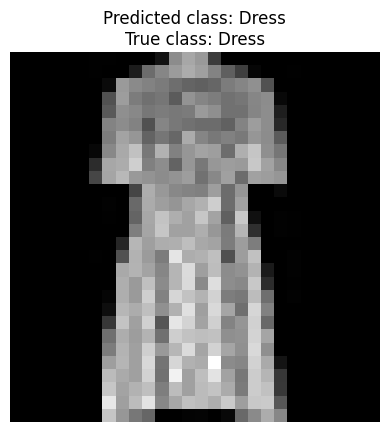

In [114]:
#@title Slider to look for some prediction examples {run: "auto"}
batch_idx = 123 #@param {type:"slider", min:0, max:9999, step:1}
pic_idx = 0 #@param {type:"slider", min:0, max:31, step:1}

batch_gambar, batch_label = fashion_val_list[batch_idx]

satu_gambar = batch_gambar[pic_idx].to(device)
label_true_idx = batch_label[pic_idx].item()
label_pred_idx = torch.argmax(fashion_model(satu_gambar)).item()

plt.imshow(satu_gambar.cpu().squeeze(), cmap='gray')
plt.title(
    f"Predicted class: {nama_kelas[label_pred_idx]}\n" +
    f"True class: {nama_kelas[label_true_idx]}"
)
plt.axis('OFF')
plt.show()

## Menyimpan parameter model

In [115]:
torch.save(fashion_model.state_dict(), "./fashion_model_state.pth")

# Referensi

Internet

- <https://paperswithcode.com/trends>

- <https://pytorch.org/docs/stable/index.html>

Sumber belajar PyTorch, *deep learning*, atau semacamnya, untuk belajar lebih lanjut

- <https://www.learnpytorch.io/>

- Buku *Dive into Deep Learning* (biasa disebut D2L), utamanya menggunakan PyTorch: <https://d2l.ai/>

- Situs bernama *"weights and biases"* (wandb) menyediakan layanan pemantauan proses *training*: <https://wandb.ai/site>